In [34]:
import numpy as np
import pandas as pd
import os, json
import re
import matplotlib.pyplot as plt

In [ ]:
def _load_json(path: str, verbose: bool = False):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except FileNotFoundError:
        if verbose:
            print(f"[missing] {path}")
        return None

def _pick_results_json_file(dir_path: str, verbose: bool = False):
    if not os.path.exists(dir_path):
        if verbose:
            print(f"[missing dir] {dir_path}")
        return None
    files = [f for f in os.listdir(dir_path) if f.endswith(".json")]
    if not files:
        if verbose:
            print(f"[no json] {dir_path}")
        return None

    # Prefer aggregated file names if present
    prefer = [f for f in files if f.startswith("results_among_")]
    if prefer:
        fname = sorted(prefer)[-1]
    else:
        fname = sorted(files)[0] if len(files) == 1 else sorted(files)[-1]
        if verbose and len(files) > 1:
            print(f"[warn] multiple json files in {dir_path}, picking: {fname}")

    return os.path.join(dir_path, fname)

def get_result_json_B(dataset, encoder, model, root, attack: bool, verbose: bool = False):
    """Backward-compat path:
    {root}/{dataset}/{encoder}/{model}/{clean|B_eval}/{ts1}/{dataset}/{encoder}/{model}/{ts2}/results*.json
    """
    attack_ = "B_eval" if attack else "clean"
    log_dir = os.path.join(root, dataset, encoder, model, attack_)
    if not os.path.exists(log_dir):
        if verbose:
            print(f"[missing dir] {log_dir}")
        return None

    timestamps = sorted(os.listdir(log_dir))
    if not timestamps:
        if verbose:
            print(f"[no timestamps] {log_dir}")
        return None
    latest_timestamp = timestamps[-1]

    log_dir = os.path.join(log_dir, latest_timestamp, dataset, encoder, model)
    if not os.path.exists(log_dir):
        if verbose:
            print(f"[missing dir] {log_dir}")
        return None

    timestamps = sorted(os.listdir(log_dir))
    if not timestamps:
        if verbose:
            print(f"[no timestamps] {log_dir}")
        return None
    latest_timestamp = timestamps[-1]

    log_dir = os.path.join(log_dir, latest_timestamp)
    if not os.path.exists(log_dir):
        if verbose:
            print(f"[missing dir] {log_dir}")
        return None

    json_path = _pick_results_json_file(log_dir, verbose=verbose)
    if json_path is None:
        return None

    # Optional consistency check (seed dirs vs filename)
    try:
        files = os.listdir(log_dir)
        num_seeds = len([f for f in files if f.startswith("seed")])
        if num_seeds > 0 and f"{num_seeds}_seeds" not in os.path.basename(json_path):
            if verbose:
                print(f"[warn] seed count ({num_seeds}) not reflected in filename: {os.path.basename(json_path)}")
    except Exception:
        pass

    return _load_json(json_path, verbose=verbose)

def get_result_json(dataset, encoder, model, root, attack: bool = False, verbose: bool = False):
    """Common path:
    {root}/{dataset}/{encoder}/{model}/{timestamp}/results*.json

    If multiple jsons exist or the layout is different, falls back to get_result_json_B.
    """
    log_dir = os.path.join(root, dataset, encoder, model)
    if not os.path.exists(log_dir):
        if verbose:
            print(f"[missing dir] {log_dir}")
        return None

    timestamps = sorted(os.listdir(log_dir))
    if not timestamps:
        if verbose:
            print(f"[no timestamps] {log_dir}")
        return None
    latest_timestamp = timestamps[-1]

    log_dir = os.path.join(log_dir, latest_timestamp)
    if not os.path.exists(log_dir):
        if verbose:
            print(f"[missing dir] {log_dir}")
        return None

    # If there are multiple json files here, this might be a different layout
    json_files = [f for f in os.listdir(log_dir) if f.endswith(".json")]
    if len(json_files) != 1:
        return get_result_json_B(dataset, encoder, model, root, attack, verbose)

    json_path = os.path.join(log_dir, json_files[0])

    # Optional consistency check (seed dirs vs filename)
    try:
        files = os.listdir(log_dir)
        num_seeds = len([f for f in files if f.startswith("seed")])
        if num_seeds > 0 and f"{num_seeds}_seeds" not in os.path.basename(json_path):
            if verbose:
                print(f"[warn] seed count ({num_seeds}) not reflected in filename: {os.path.basename(json_path)}")
    except Exception:
        pass

    return _load_json(json_path, verbose=verbose)


In [3]:
def show_results(df:pd.DataFrame, model_name:str):
    for dataset in df["dataset"].unique():
        backbone = "backbone" if "backbone" in df.columns else "encoder"
        for bb in df[backbone].unique():
            row = df[(df["dataset"]==dataset) & (df[backbone]==bb) & (df["model"]==model_name)].iloc[0]
            print(f"Dataset: {dataset}, Backbone: {bb}, Model: {model_name}")
            print(f"{row['AUC_mean']*100:.2f} ± {row['AUC_std']*100:.2f}")
            print(f"{row['F1_mean']*100:.2f} ± {row['F1_std']*100:.2f}")
            print(f"{row['DP_mean']*100:.2f} ± {row['DP_std']*100:.2f}")
            print(f"{row['EO_mean']*100:.2f} ± {row['EO_std']*100:.2f}")
            print('--------------------------------')

In [4]:
def collect_rerun_results(datasets, encoders, models, path, attack_mode:str, verbose=False):
    lst_results = []
    for dataset in datasets:
        for encoder in encoders:
            for model in models:
                results = get_result_json(dataset, encoder, model, path, attack_mode != "no_attack", verbose)
                if results is None:
                    continue
                results['results']["dataset"] = dataset
                results['results']["encoder"] = encoder
                results['results']["model"] = model
                results['results']["attack_mode"] = attack_mode
                lst_results.append(results['results'])
    df_results = pd.DataFrame(lst_results).sort_values(by=["dataset", "encoder", "model"])
    return df_results

def concat_clean_and_attacked_results(df_clean:pd.DataFrame, df_attack:pd.DataFrame, attack_mode:str, include_ratio:bool=True):
    assert np.array_equal(
        df_clean[["dataset", "encoder"]].values,
        df_attack[["dataset", "encoder"]].values
    )
    numeric_cols = [col for col in df_clean.columns if df_clean[col].dtype in [np.float64, np.float32, np.int64, np.int32] and col not in ["dataset", "encoder", "model"]]
    if include_ratio:
        df_ratio = df_attack.copy()
        for col in numeric_cols:
            df_ratio[col] = df_attack[col] / df_clean[col]
        df_ratio[["dataset", "encoder", "model"]] = df_attack[["dataset", "encoder", "model"]]
        df_ratio["attack_mode"] = "ratio"
        df_concat = pd.concat([df_clean, df_attack, df_ratio], ignore_index=True)
        df_concat["attack_mode"] = pd.Categorical(df_concat["attack_mode"], categories=["none", attack_mode, "ratio"], ordered=True)
    else:
        df_concat = pd.concat([df_clean, df_attack], ignore_index=True)
        df_concat["attack_mode"] = pd.Categorical(df_concat["attack_mode"], categories=["none", attack_mode], ordered=True)
    df_concat = df_concat.sort_values(by=["dataset", "encoder", "model", "attack_mode"])
    df_concat = df_concat[["dataset", "encoder", "model", "attack_mode"] + numeric_cols]
    return df_concat

In [5]:
from pathlib import Path

def collect_results_among_seeds(
    exp_dir: str,
    pattern: str = "results_among_*_seeds.json",
    verbose: bool = False,
):
    """Collect aggregated JSON results (e.g., results_among_10_seeds.json) under an experiment directory.

    Expected layout (most common):
        exp_dir/<method>/<dataset>/<encoder>/<model>/<timestamp>/results_among_*_seeds.json

    This function is robust to exp_dir depth by reading metadata from the last 5 folders above the JSON file.
    It also tolerates JSONs that either:
        - have a top-level key "results" (preferred), or
        - store metrics directly at the top level.
    """
    exp_dir = Path(exp_dir)
    if not exp_dir.exists():
        raise FileNotFoundError(f"exp_dir not found: {exp_dir.resolve()}")
    rows = []

    for p in exp_dir.rglob(pattern):
        try:
            rel = p.relative_to(exp_dir)
        except Exception:
            rel = None

        # metadata from directory names (closest parents)
        timestamp = p.parent.name
        model = p.parent.parent.name
        encoder = p.parent.parent.parent.name
        dataset = p.parent.parent.parent.parent.name
        method = rel.parts[0] if (rel is not None and len(rel.parts) > 0) else p.parent.parent.parent.parent.parent.name

        obj = _load_json(str(p), verbose=verbose)
        if obj is None:
            continue
        res = obj.get("results", obj)
        if not isinstance(res, dict):
            if verbose:
                print(f"[skip] unexpected json format: {p}")
            continue

        row = dict(res)
        row["method"] = method
        row["dataset"] = dataset
        row["encoder"] = encoder
        row["model"] = model
        row["timestamp"] = timestamp

        # parse seed count from filename if present
        m = re.search(r"results_among_(\d+)_seeds", p.name)
        if m:
            row["n_seeds"] = int(m.group(1))

        rows.append(row)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        if verbose:
            print(f"[empty] No files matched {pattern} under {exp_dir}")
        return df

    # keep a nice order if columns exist
    front = [c for c in ["method", "dataset", "encoder", "model", "timestamp", "n_seeds"] if c in df.columns]
    rest = [c for c in df.columns if c not in front]
    df = df[front + rest].sort_values(by=[c for c in front if c in df.columns])
    return df


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Helper to plot a pivot as a heatmap
def heatmap_from_pivot(
    pivot,
    title: str,
    xlabel="encoder",
    ylabel="dataset",
    vcenter=0.0,                 # center (0 for delta)
    symmetric=True,              # use symmetric range around vcenter
    neg_color="#2166AC",         # negative side color
    zero_color="#F7F7F7",        # center color
    pos_color="#B2182B",         # positive side color
    cbar_label=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    data = pivot.values.astype(float)

    # --- diverging colormap with two obvious colors + neutral center ---
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "neg_pos", [neg_color, zero_color, pos_color]
    )

    # --- normalization: map vcenter (0) to the neutral color ---
    if symmetric:
        absmax = np.nanmax(np.abs(data - vcenter))
        vmin, vmax = vcenter - absmax, vcenter + absmax
    else:
        vmin, vmax = np.nanmin(data), np.nanmax(data)

    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    fig = plt.figure(figsize=(5.5, 3.8), dpi=150)
    ax = plt.gca()

    im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns.tolist())
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index.tolist())

    # annotate values
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", fontsize=7)

    # colorbar tuning
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label is not None:
        cbar.set_label(cbar_label)
    cbar.set_ticks([vmin, vcenter, vmax])  # show neg / zero / pos anchors

    plt.tight_layout()
    plt.show()

# 06 Feb 2026

In [7]:
EXP_DIR = "../logs/compare_edgeadder_vs_advtrain_expB"

In [18]:
df_compare = collect_results_among_seeds(EXP_DIR, verbose=True)
df_compare["method"] = pd.Categorical(df_compare["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_compare.shape

(80, 17)

In [19]:
df_compare.columns

Index(['method', 'dataset', 'encoder', 'model', 'timestamp', 'n_seeds',
       'AUC_mean', 'AUC_std', 'F1_mean', 'F1_std', 'ACC_mean', 'ACC_std',
       'DP_mean', 'DP_std', 'EO_mean', 'EO_std', 'name'],
      dtype='object')

In [20]:
df_compare["method"].value_counts()

method
vanilla             27
vanilla_advtrain    27
edge_adder          26
Name: count, dtype: int64

In [21]:
C_10seeds = df_compare["n_seeds"] == 10
df_compare[C_10seeds].shape

(75, 17)

In [55]:
df_compare[C_10seeds].to_csv("df_compare_vanilla_ea_adv.csv", index=False)

In [25]:
pts = {}

In [28]:
metric = "DP_mean"
pts[metric] = df_compare[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            7.26   8.76  10.28   4.42   4.62
        edge_adder         5.92   7.46   7.54  10.34   6.06
        vanilla_advtrain   7.53   8.30  10.88   2.12   4.26
german  vanilla            2.28   6.97  13.69  19.94  11.05
        edge_adder         6.06   2.71   3.31   5.44   2.29
        vanilla_advtrain   0.92   6.39  13.42  28.67  11.31
nba     vanilla           23.54  51.12  11.24   9.43  47.54
        edge_adder        20.05  28.24   6.62  10.03  37.32
        vanilla_advtrain  22.77  41.17  23.72  12.85  37.65
pokec_n vanilla           29.61  22.13  35.31  28.78  30.12
        edge_adder        26.70   7.52  28.43   3.55   6.59
        vanilla_advtrain   9.87   8.82  20.11  11.17  24.49
pokec_z vanilla           40.60  31.37  39.02  28.48  37.10
        edge_adder        16.95   9.57  17.01  17.77   5.23
        vanilla_advtrain   9.56  11.34  20.85  11.31  12.91

In [29]:
metric = "EO_mean"
pts[metric] = df_compare[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            4.91   4.30   6.43   1.76   2.70
        edge_adder         3.42   3.14   5.83   8.52   3.11
        vanilla_advtrain   4.97   4.21   7.13   1.30   2.82
german  vanilla            2.80   6.05  10.11  20.34  10.75
        edge_adder         7.44   2.17   4.88   2.63   1.97
        vanilla_advtrain   0.83   5.17  10.41  22.07   9.67
nba     vanilla           23.00  33.67   7.33   8.67  41.00
        edge_adder        22.00  13.00   8.67  10.00  26.33
        vanilla_advtrain  16.67  22.67  18.67   9.00  34.00
pokec_n vanilla           26.73  20.97  34.50  24.67  28.67
        edge_adder        23.70   7.36  24.71   1.97   5.83
        vanilla_advtrain  10.70   8.53  20.09  10.28  25.15
pokec_z vanilla           33.37  26.25  38.08  26.04  29.42
        edge_adder        14.66   8.23  17.42  14.92   4.64
        vanilla_advtrain   9.73  10.25  20.84  10.98  11.14

In [30]:
metric = "F1_mean"
pts[metric] = df_compare[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           84.30  77.51  70.28  80.69  80.23
        edge_adder        79.50  79.80  72.77  80.31  80.25
        vanilla_advtrain  84.13  78.69  70.69  81.94  80.71
german  vanilla           43.70  49.42  74.54  61.07  68.71
        edge_adder        67.20  34.74  53.19  77.59  63.26
        vanilla_advtrain  59.00  57.34  67.89  73.87  67.37
nba     vanilla           64.65  69.65  55.24  56.48  65.33
        edge_adder        67.45  72.63  47.24  55.27  65.75
        vanilla_advtrain  68.74  71.80  53.57  58.08  66.29
pokec_n vanilla           63.67  65.65  57.90  65.57  65.61
        edge_adder        61.25  67.51  61.97  67.06  67.66
        vanilla_advtrain  63.13  65.40  57.81  65.96  65.35
pokec_z vanilla           66.66  68.14  58.99  61.47  68.09
        edge_adder        68.27  70.32  64.42  71.80  68.85
        vanilla_advtrain  66.68  69.01  62.89  66.24  69.74

In [31]:
metric = "AUC_mean"
pts[metric] = df_compare[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           93.00  88.35  83.30  91.30  90.10
        edge_adder        90.12  89.45  83.90  90.23  89.70
        vanilla_advtrain  93.42  88.67  83.75  91.14  90.13
german  vanilla           50.38  55.60  70.76  67.37  60.06
        edge_adder        61.37  53.78  62.74  72.14  54.32
        vanilla_advtrain  49.76  54.87  69.37  70.27  59.96
nba     vanilla           66.88  71.59  60.67  65.28  73.46
        edge_adder        72.63  75.67  61.06  62.29  73.67
        vanilla_advtrain  71.54  75.59  60.29  64.49  74.89
pokec_n vanilla           69.78  74.11  62.96  68.22  72.52
        edge_adder        61.57  76.51  68.62  74.83  75.43
        vanilla_advtrain  74.86  75.71  68.92  73.62  73.76
pokec_z vanilla           70.57  75.58  66.32  69.90  74.09
        edge_adder        66.46  78.04  70.51  77.87  76.75
        vanilla_advtrain  75.18  77.59  71.12  76.04  75.55

In [36]:
def plot_metric_heatmap(pt: pd.DataFrame, title: str = "", annotate: bool = True):
    """
    pt: DataFrame shaped (rows = MultiIndex [dataset, method], cols = encoders),
        values are already in the display unit (e.g., percent).
    """
    # Ensure consistent ordering (optional but usually helpful)
    if isinstance(pt.index, pd.MultiIndex) and pt.index.nlevels >= 2:
        pt = pt.sort_index(level=list(range(pt.index.nlevels)))

    data = pt.to_numpy(dtype=float)
    nrows, ncols = data.shape

    fig_h = max(4, 0.45 * nrows)   # auto-ish sizing
    fig_w = max(6, 1.0 * ncols)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(data, aspect="auto")  # uses matplotlib default colormap
    cbar = fig.colorbar(im, ax=ax)
    if title:
        ax.set_title(title)

    # X ticks (encoders)
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels([str(c).upper() for c in pt.columns], rotation=0)

    # Y tick labels: show dataset once per block
    if isinstance(pt.index, pd.MultiIndex) and pt.index.nlevels >= 2:
        labels = []
        prev_ds = None
        for ds, method in pt.index:
            if ds != prev_ds:
                labels.append(f"{ds} | {method}")
                prev_ds = ds
            else:
                labels.append(f"{'':{len(str(prev_ds))}} | {method}")
        ax.set_yticks(np.arange(nrows))
        ax.set_yticklabels(labels)
    else:
        ax.set_yticks(np.arange(nrows))
        ax.set_yticklabels([str(i) for i in pt.index])

    # Thin gridlines between cells (no manual colors)
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Thick separators between datasets
    if isinstance(pt.index, pd.MultiIndex) and pt.index.nlevels >= 2:
        ds_level = pt.index.get_level_values(0).to_numpy()
        breaks = np.where(ds_level[:-1] != ds_level[1:])[0] + 1
        for b in breaks:
            ax.axhline(b - 0.5, linewidth=2)

    # Cell annotations
    if annotate:
        # Choose text color based on background intensity
        norm = im.norm
        for i in range(nrows):
            for j in range(ncols):
                v = pt.iat[i, j]
                if pd.isna(v):
                    continue
                txt_color = "w" if norm(v) > 0.6 else "k"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9, color=txt_color)

    ax.set_xlabel("Encoder")
    ax.set_ylabel("Dataset | Method")
    plt.tight_layout()
    return fig, ax

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def delta_vs_vanilla(pt_percent: pd.DataFrame, method: str) -> pd.DataFrame:
    """
    pt_percent: index=[dataset, method], columns=[encoder], values in %
    returns: index=[dataset], columns=[encoder], values = (method - vanilla)
    """
    base = pt_percent.xs("vanilla", level="method")
    tgt  = pt_percent.xs(method, level="method")
    return (tgt - base).sort_index()

def plot_delta_heatmaps(pt_percent: pd.DataFrame, methods=("edge_adder", "vanilla_advtrain"), metric_name="DP_mean (%)"):
    deltas = [delta_vs_vanilla(pt_percent, m) for m in methods]

    # shared symmetric range around 0
    all_vals = np.concatenate([d.to_numpy().ravel() for d in deltas])
    vmax = np.nanmax(np.abs(all_vals))
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    fig_h = max(4, 0.45 * deltas[0].shape[0])
    fig_w = max(10, 1.2 * deltas[0].shape[1] * len(methods))
    fig, axes = plt.subplots(1, len(methods), figsize=(fig_w, fig_h), sharey=True)

    if len(methods) == 1:
        axes = [axes]

    for ax, d, m in zip(axes, deltas, methods):
        im = ax.imshow(d.to_numpy(dtype=float), aspect="auto", norm=norm)  # default colormap
        ax.set_title(f"Δ {metric_name}\n({m} − vanilla)")

        # ticks
        ax.set_xticks(np.arange(d.shape[1]))
        ax.set_xticklabels([str(c).upper() for c in d.columns], rotation=0)
        ax.set_yticks(np.arange(d.shape[0]))
        ax.set_yticklabels([str(i) for i in d.index])

        # gridlines
        ax.set_xticks(np.arange(-0.5, d.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, d.shape[0], 1), minor=True)
        ax.grid(which="minor", linestyle="-", linewidth=0.5)
        ax.tick_params(which="minor", bottom=False, left=False)

        # annotate cells
        for i in range(d.shape[0]):
            for j in range(d.shape[1]):
                v = d.iat[i, j]
                if pd.isna(v):
                    continue
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9)

        ax.set_xlabel("Encoder")

    axes[0].set_ylabel("Dataset")

    # one shared colorbar
    cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label(f"Δ {metric_name}")

    plt.tight_layout()
    return fig, axes

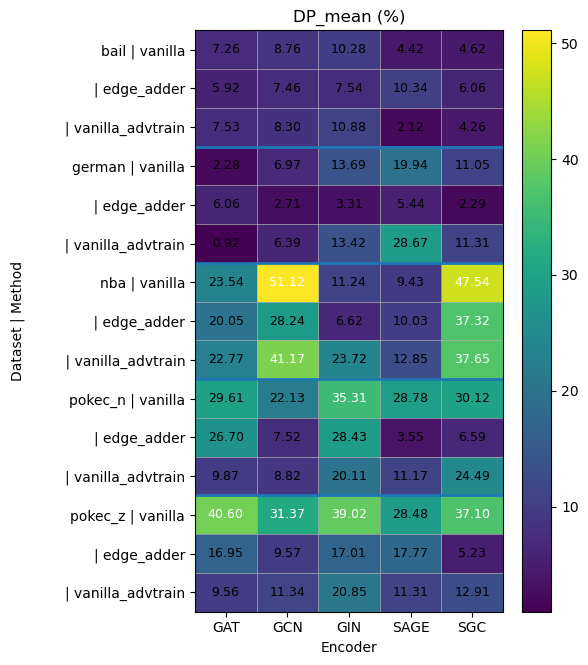

In [ ]:
metric = "DP_mean"
pt = (pts[metric] * 100).round(2)
plot_metric_heatmap(pt, title=f"{metric} (%)", annotate=True)
plt.show()

/tmp/ipykernel_3791361/127163005.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


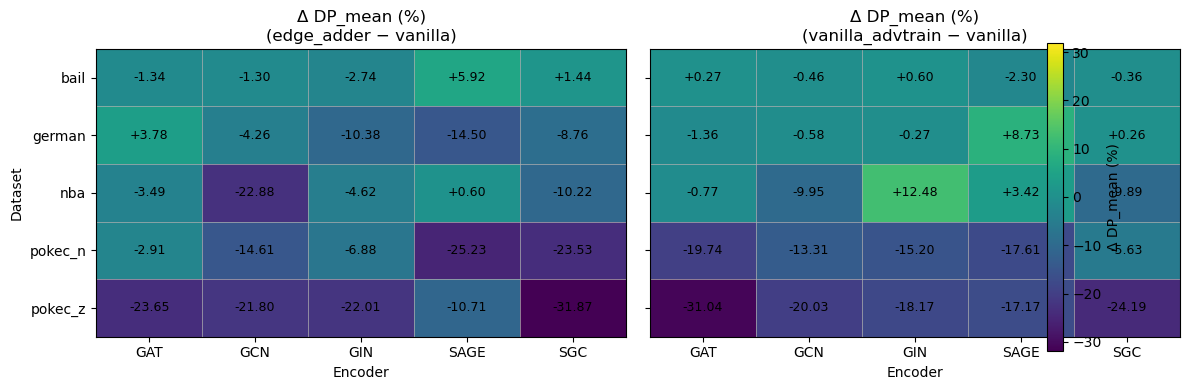

In [37]:
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)
plot_delta_heatmaps(pt_percent, methods=("edge_adder", "vanilla_advtrain"), metric_name="DP_mean (%)")
plt.show()

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

def plot_dumbbell_vs_vanilla(
    pt_percent: pd.DataFrame,                 # index=[dataset, method], cols=[encoder], values in %
    target_method: str = "edge_adder",
    baseline_method: str = "vanilla",
    metric_label: str = "DP_mean (%)",
    ncols: int = 3,
    annotate_delta: bool = True,
    sort_encoders_by_delta: bool = False,
):
    assert isinstance(pt_percent.index, pd.MultiIndex), "pt_percent must have MultiIndex index=[dataset, method]"
    assert "method" in pt_percent.index.names and "dataset" in pt_percent.index.names, \
        f"Expect index names include 'dataset' and 'method', got {pt_percent.index.names}"

    datasets = list(pt_percent.index.get_level_values("dataset").unique())
    encoders = list(pt_percent.columns)

    # Optional: determine a consistent x-range across panels
    base = pt_percent.xs(baseline_method, level="method")
    tgt  = pt_percent.xs(target_method, level="method")
    all_vals = np.concatenate([base.to_numpy().ravel(), tgt.to_numpy().ravel()])
    xmin, xmax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.05 * (xmax - xmin + 1e-9)
    xlim = (xmin - pad, xmax + pad)

    nrows = ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, max(3.5, 0.9 * nrows * len(encoders) / 3)), sharex=True)
    axes = np.array(axes).reshape(-1)

    # Legend proxies (no manual colors)
    proxy_v = plt.Line2D([0], [0], marker="o", linestyle="None", label=baseline_method)
    proxy_t = plt.Line2D([0], [0], marker="D", linestyle="None", label=target_method)

    for k, ds in enumerate(datasets):
        ax = axes[k]

        x0 = pt_percent.loc[(ds, baseline_method), encoders].to_numpy(dtype=float)
        x1 = pt_percent.loc[(ds, target_method),  encoders].to_numpy(dtype=float)

        # Optionally sort encoders by delta magnitude within each dataset
        order = np.arange(len(encoders))
        if sort_encoders_by_delta:
            order = np.argsort((x1 - x0))  # from most negative to most positive
        enc_ord = [encoders[i] for i in order]
        x0, x1 = x0[order], x1[order]

        y = np.arange(len(enc_ord))

        # Draw one dumbbell per encoder
        for i in range(len(enc_ord)):
            # line
            (ln,) = ax.plot([x0[i], x1[i]], [y[i], y[i]], linewidth=2)
            c = ln.get_color()  # reuse the same auto color for both endpoints

            # endpoints
            ax.scatter([x0[i]], [y[i]], marker="o", s=50, color=c, zorder=3)
            ax.scatter([x1[i]], [y[i]], marker="D", s=55, color=c, zorder=3)

            if annotate_delta and np.isfinite(x0[i]) and np.isfinite(x1[i]):
                dx = x1[i] - x0[i]
                ax.text(max(x0[i], x1[i]) + 0.01*(xlim[1]-xlim[0]), y[i], f"{dx:+.2f}",
                        va="center", fontsize=9)

        ax.set_title(str(ds))
        ax.set_yticks(y)
        ax.set_yticklabels([e.upper() for e in enc_ord])
        ax.set_xlim(*xlim)
        ax.grid(True, axis="x", linewidth=0.6)

        if k % ncols == 0:
            ax.set_ylabel("Encoder")
        ax.set_xlabel(metric_label)

    # Hide unused axes
    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")

    fig.legend(handles=[proxy_v, proxy_t], loc="upper right", frameon=True)
    plt.tight_layout()
    return fig, axes

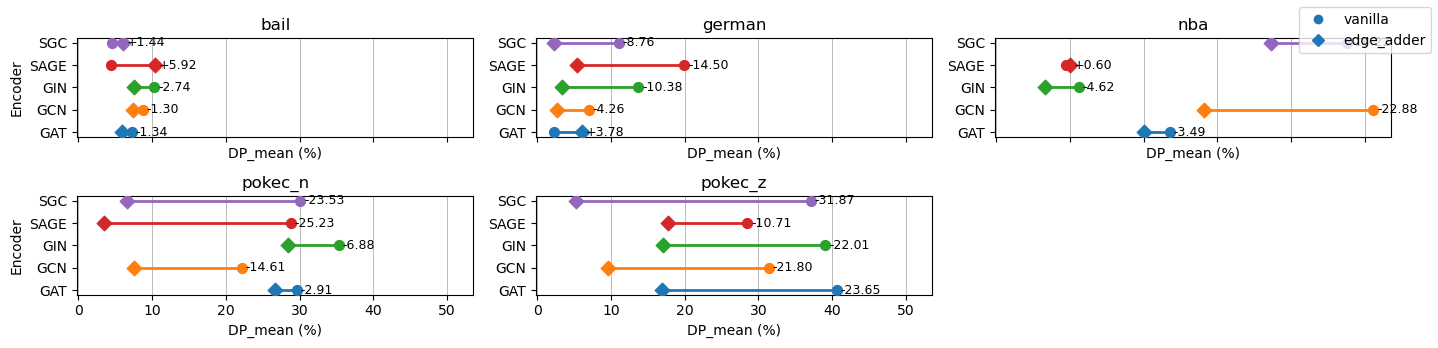

In [39]:
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_dumbbell_vs_vanilla(
    pt_percent,
    target_method="edge_adder",        # or "vanilla_advtrain"
    baseline_method="vanilla",
    metric_label="DP_mean (%)",
    annotate_delta=True,
    sort_encoders_by_delta=False,      # set True if you want strongest effects grouped
)
plt.show()

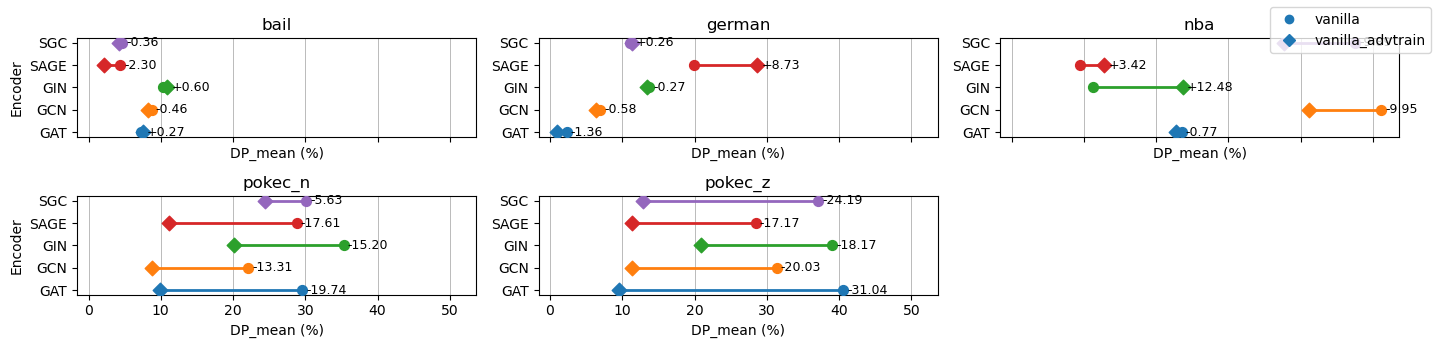

In [40]:
plot_dumbbell_vs_vanilla(
    pt_percent,
    target_method="vanilla_advtrain",        # or "vanilla_advtrain"
    baseline_method="vanilla",
    metric_label="DP_mean (%)",
    annotate_delta=True,
    sort_encoders_by_delta=False,      # set True if you want strongest effects grouped
)
plt.show()

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

def plot_grouped_bars_per_dataset(
    pt_percent: pd.DataFrame,                      # index=[dataset, method], cols=[encoder]
    methods=("vanilla", "vanilla_advtrain", "edge_adder"),
    metric_label="DP_mean (%)",
    ncols=3,
    rotate_xticks=0,
    value_fmt="{:.2f}",            # <-- added
    label_padding=2,               # <-- added (points)
):
    assert isinstance(pt_percent.index, pd.MultiIndex), "pt_percent must have MultiIndex index=[dataset, method]"
    assert "dataset" in pt_percent.index.names and "method" in pt_percent.index.names, \
        f"Expect index names include 'dataset' and 'method', got {pt_percent.index.names}"

    datasets = list(pt_percent.index.get_level_values("dataset").unique())
    encoders = list(pt_percent.columns)

    # Shared y-limits across all panels
    vals = []
    for ds in datasets:
        for m in methods:
            if (ds, m) in pt_percent.index:
                vals.append(pt_percent.loc[(ds, m), encoders].to_numpy(dtype=float))
    all_vals = np.concatenate([v.ravel() for v in vals]) if vals else np.array([0.0])
    ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.08 * (ymax - ymin + 1e-9)
    ylim = (ymin - pad, ymax + pad)

    nrows = ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), sharey=True)
    axes = np.array(axes).reshape(-1)

    x = np.arange(len(encoders))
    k = len(methods)
    width = min(0.22, 0.8 / k)  # keep bars readable

    for i, ds in enumerate(datasets):
        ax = axes[i]

        for j, m in enumerate(methods):
            if (ds, m) not in pt_percent.index:
                continue
            y = pt_percent.loc[(ds, m), encoders].to_numpy(dtype=float)

            bars = ax.bar(x + (j - (k - 1) / 2) * width, y, width=width, label=m)

            # ---- add value labels on top of each bar ----
            labels = [("" if np.isnan(v) else value_fmt.format(v)) for v in y]
            ax.bar_label(bars, labels=labels, padding=label_padding, fontsize=9)
            # --------------------------------------------

        ax.set_title(str(ds))
        ax.set_xticks(x)
        ax.set_xticklabels([e.upper() for e in encoders], rotation=rotate_xticks)
        ax.set_ylim(*ylim)
        ax.grid(True, axis="y", linewidth=0.6)
        ax.set_xlabel("Encoder")

        if i % ncols == 0:
            ax.set_ylabel(metric_label)

        # Keep legend only on first subplot (less clutter)
        if i == 0:
            ax.legend(frameon=True)

    # Hide unused axes
    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    return fig, axes

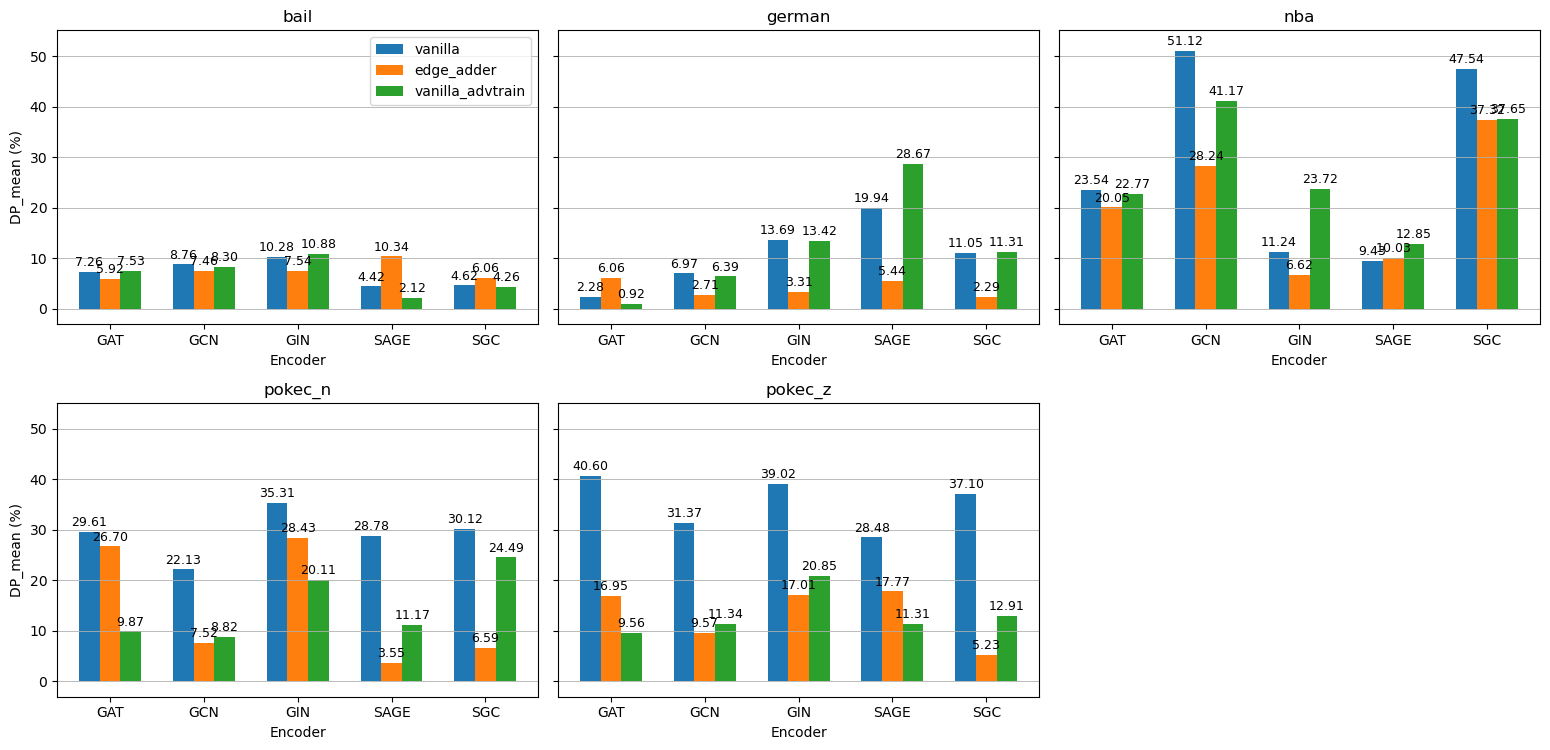

In [87]:
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="DP_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

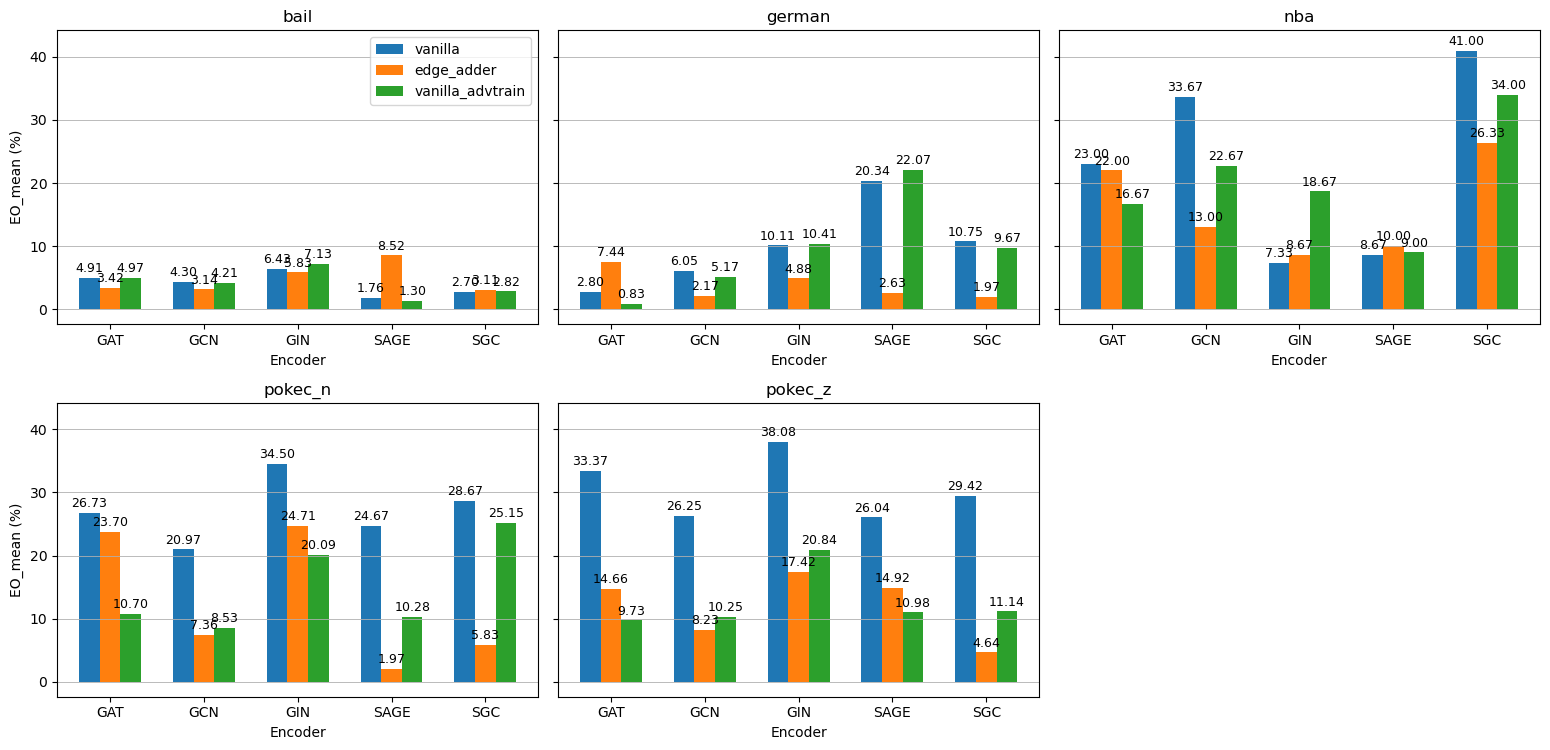

In [88]:
metric = "EO_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="EO_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

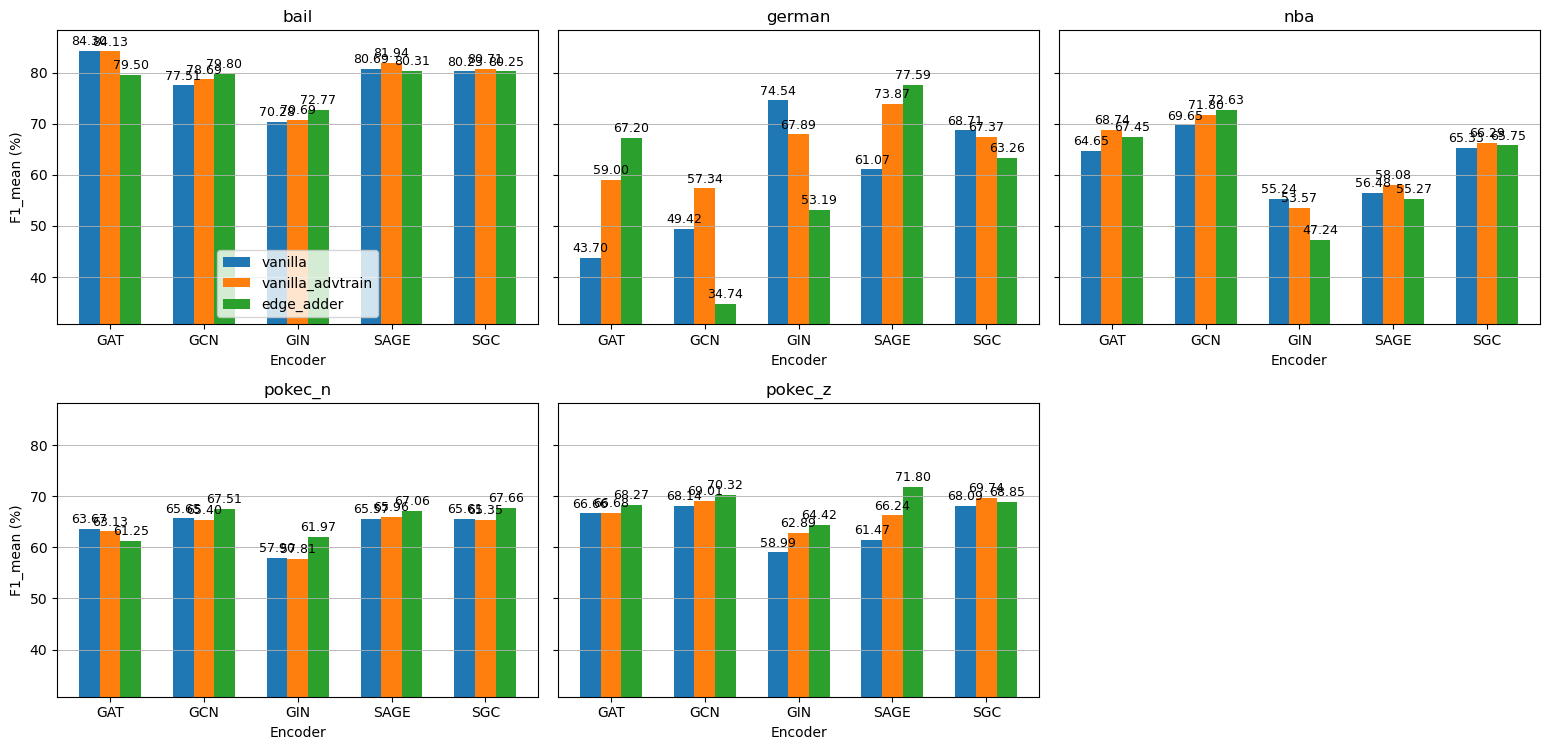

In [58]:
metric = "F1_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "vanilla_advtrain", "edge_adder"),
    metric_label="F1_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

In [45]:
# pt_percent: index=[dataset, method], cols=[encoder], values in %
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)

(
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)  # scale bars per COLUMN (encoder) across all rows
)

In [59]:
# pt_percent: index=[dataset, method], cols=[encoder], values in %
metric = "F1_mean"
pt_percent = (pts[metric] * 100).round(2)

(
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)  # scale bars per COLUMN (encoder) across all rows
)

In [46]:
html = (
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)
    .to_html()
)
with open("dp_table_with_bars.html", "w", encoding="utf-8") as f:
    f.write(html)

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_table_with_bars(
    pt_percent: pd.DataFrame,                # index=[dataset, method], cols=[encoder], values in %
    title: str = "",
    scale: str = "col",                      # "col" or "global"
    fmt: str = "{:.2f}",
):
    pt = pt_percent.copy()
    data = pt.to_numpy(dtype=float)
    nrows, ncols = data.shape

    # normalization
    if scale == "col":
        vmax = np.nanmax(data, axis=0)
        vmax[vmax == 0] = 1.0
        norm = data / vmax
    elif scale == "global":
        vmax = np.nanmax(data)
        vmax = 1.0 if (not np.isfinite(vmax) or vmax == 0) else vmax
        norm = data / vmax
    else:
        raise ValueError("scale must be 'col' or 'global'")

    # figure sizing
    fig_h = max(4, 0.42 * nrows)
    fig_w = max(7, 1.15 * ncols)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.invert_yaxis()

    # draw grid + bars + text
    for i in range(nrows):
        for j in range(ncols):
            v = pt.iat[i, j]
            # cell border
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, linewidth=0.6))
            if pd.isna(v):
                continue

            # bar inside cell (use default color, only set alpha)
            w = float(np.clip(norm[i, j], 0, 1)) * 0.92
            ax.add_patch(Rectangle((j + 0.04, i + 0.12), w, 0.76, alpha=0.35))

            # value text
            ax.text(j + 0.5, i + 0.5, fmt.format(v), ha="center", va="center", fontsize=9)

    # column labels (encoders)
    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels([str(c).upper() for c in pt.columns])

    # row labels (dataset | method)
    if isinstance(pt.index, pd.MultiIndex) and pt.index.nlevels >= 2:
        ds = pt.index.get_level_values(0).to_numpy()
        md = pt.index.get_level_values(1).to_numpy()

        # Fixed dataset-column width + extra gap so dataset and method don't feel cramped
        w_ds = max(len(str(x)) for x in ds)
        label_gap = 7                      # <-- increase if you want more separation
        sep = (" " * label_gap) # + "| "

        ylabels, prev = [], None
        for d, m in zip(ds, md):
            m = "advtrain" if m == "vanilla_advtrain" else m  # shorten method name for better fit
            if d != prev:
                ylabels.append(f"{str(d):<{w_ds}}{sep}{m}")
                prev = d
            else:
                ylabels.append(f"{'':<{w_ds}}{sep}{m}")

        ax.set_yticks(np.arange(nrows) + 0.5)
        ax.set_yticklabels(ylabels, fontfamily="monospace")  # monospace keeps spacing consistent

        # thick separators between datasets
        breaks = np.where(ds[:-1] != ds[1:])[0] + 1
        for b in breaks:
            ax.hlines(b, 0, ncols, linewidth=2)

        # Optional: push labels a bit away from the table
        ax.tick_params(axis="y", pad=8)
    else:
        ax.set_yticks(np.arange(nrows) + 0.5)
        ax.set_yticklabels([str(x) for x in pt.index])

    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig, ax

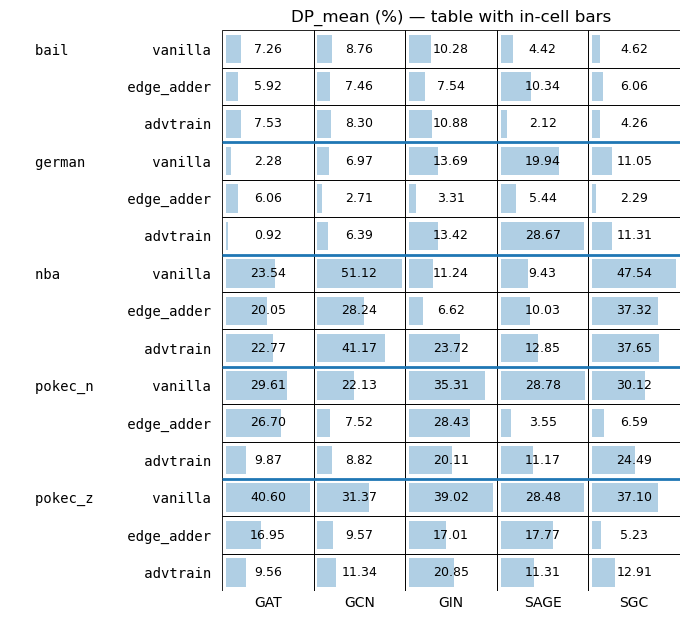

In [69]:
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="DP_mean (%) — table with in-cell bars", scale="col")
plt.show()

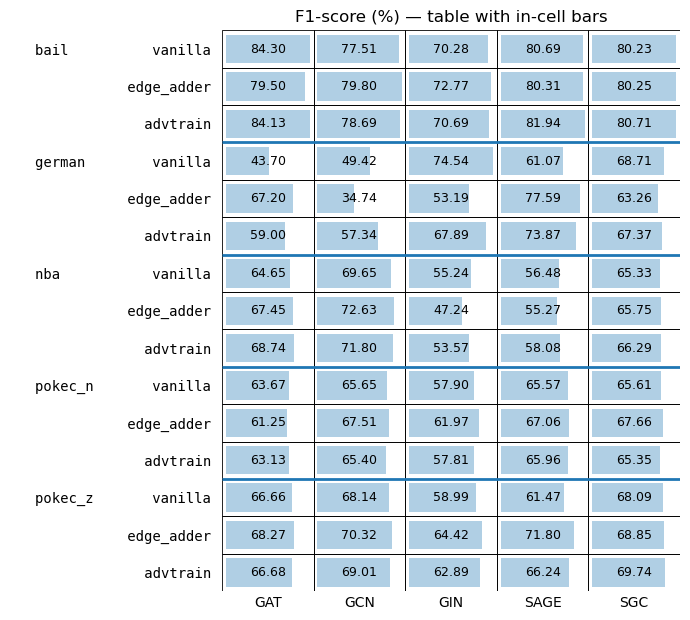

In [71]:
metric = "F1_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="F1-score (%) — table with in-cell bars", scale="col")
plt.show()

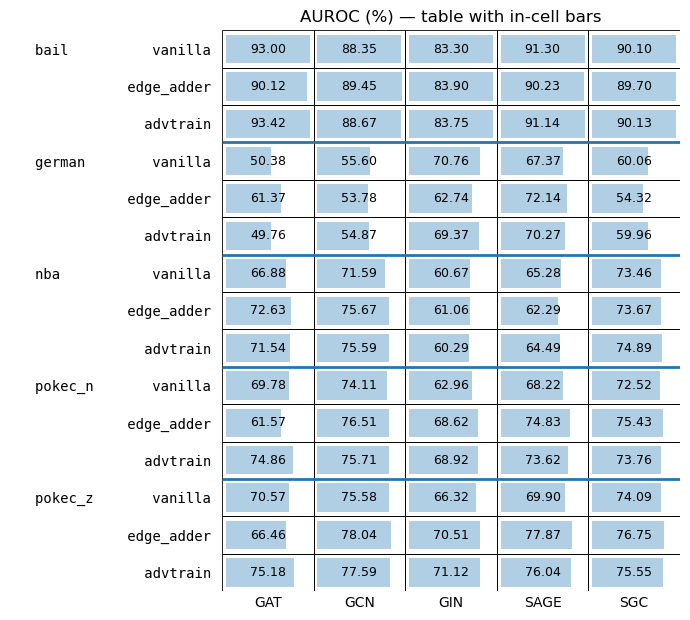

In [74]:
metric = "AUC_mean"
pt_percent = (pts[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="AUROC (%) — table with in-cell bars", scale="col")
plt.show()

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _ensure_index_names(pt: pd.DataFrame):
    # Expect MultiIndex with 2 levels: dataset, method
    if not isinstance(pt.index, pd.MultiIndex) or pt.index.nlevels < 2:
        raise ValueError("pt must have a MultiIndex with levels [dataset, method].")
    names = list(pt.index.names)
    if names[0] is None: names[0] = "dataset"
    if names[1] is None: names[1] = "method"
    pt = pt.copy()
    pt.index = pt.index.set_names(names[:2])
    return pt

def win_counts(pt_percent: pd.DataFrame, better="min"):
    """
    pt_percent: index=[dataset, method], cols=[encoder], values
    better: "min" (lower is better) or "max" (higher is better)
    returns: DataFrame index=[dataset], cols=[method], values = #wins across encoders
    """
    pt = _ensure_index_names(pt_percent)
    datasets = pt.index.get_level_values("dataset").unique()
    methods  = pt.index.get_level_values("method").unique()
    encoders = pt.columns

    out = []
    for ds in datasets:
        block = pt.xs(ds, level="dataset")  # rows=method, cols=encoder
        # winner per encoder
        if better == "min":
            winners = block.idxmin(axis=0)
        elif better == "max":
            winners = block.idxmax(axis=0)
        else:
            raise ValueError("better must be 'min' or 'max'")
        counts = winners.value_counts().reindex(methods, fill_value=0)
        out.append(counts.rename(ds))

    return pd.DataFrame(out).astype(int)

def plot_win_counts(counts: pd.DataFrame, title="Wins per dataset (#encoders where method is best)"):
    # stacked bar
    fig, ax = plt.subplots(figsize=(max(7, 1.3 * len(counts)), 4))
    bottom = np.zeros(len(counts))
    x = np.arange(len(counts))

    for m in counts.columns:
        ax.bar(x, counts[m].to_numpy(), bottom=bottom, label=str(m))
        bottom += counts[m].to_numpy()

    ax.set_xticks(x)
    ax.set_xticklabels([str(d) for d in counts.index], rotation=0)
    ax.set_ylabel("#Wins")
    ax.set_title(title)
    ax.legend(frameon=True)
    ax.grid(True, axis="y", linewidth=0.6)
    plt.tight_layout()
    return fig, ax

from math import ceil

def ranks_per_dataset(pt_percent: pd.DataFrame, better="min"):
    pt = _ensure_index_names(pt_percent)
    datasets = pt.index.get_level_values("dataset").unique()
    out = {}
    for ds in datasets:
        block = pt.xs(ds, level="dataset")  # rows=method, cols=encoder
        # rank per column (encoder)
        ascending = (better == "min")
        r = block.rank(axis=0, method="min", ascending=ascending)  # 1 best
        out[ds] = r
    return out

def plot_bump_ranks(ranks_dict, ncols=3, title_prefix="Ranks across encoders (1 = best)"):
    datasets = list(ranks_dict.keys())
    nrows = ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.8*nrows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for i, ds in enumerate(datasets):
        ax = axes[i]
        r = ranks_dict[ds]  # rows=method, cols=encoder
        x = np.arange(len(r.columns))

        for m in r.index:
            ax.plot(x, r.loc[m].to_numpy(), marker="o", label=str(m))

        ax.set_title(f"{ds}")
        ax.set_xticks(x)
        ax.set_xticklabels([str(c).upper() for c in r.columns])
        ax.set_ylim(0.5, r.shape[0] + 0.5)
        ax.invert_yaxis()  # rank 1 at top
        ax.grid(True, axis="y", linewidth=0.6)
        if i % ncols == 0:
            ax.set_ylabel("Rank (1 best)")
        ax.set_xlabel("Encoder")

        if i == 0:
            ax.legend(frameon=True)

    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title_prefix, y=1.02)
    plt.tight_layout()
    return fig, axes


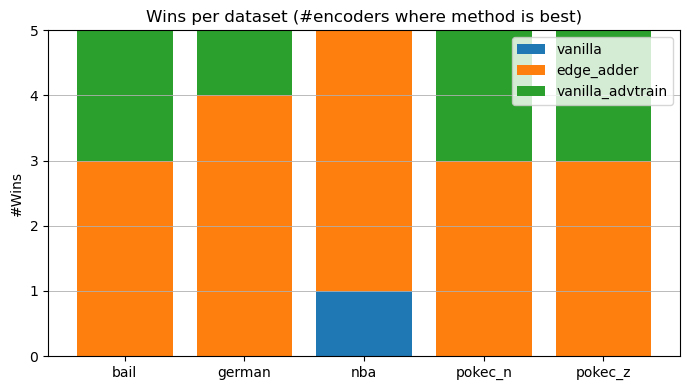

In [83]:
metric = "DP_mean"
pt_percent = (pts[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

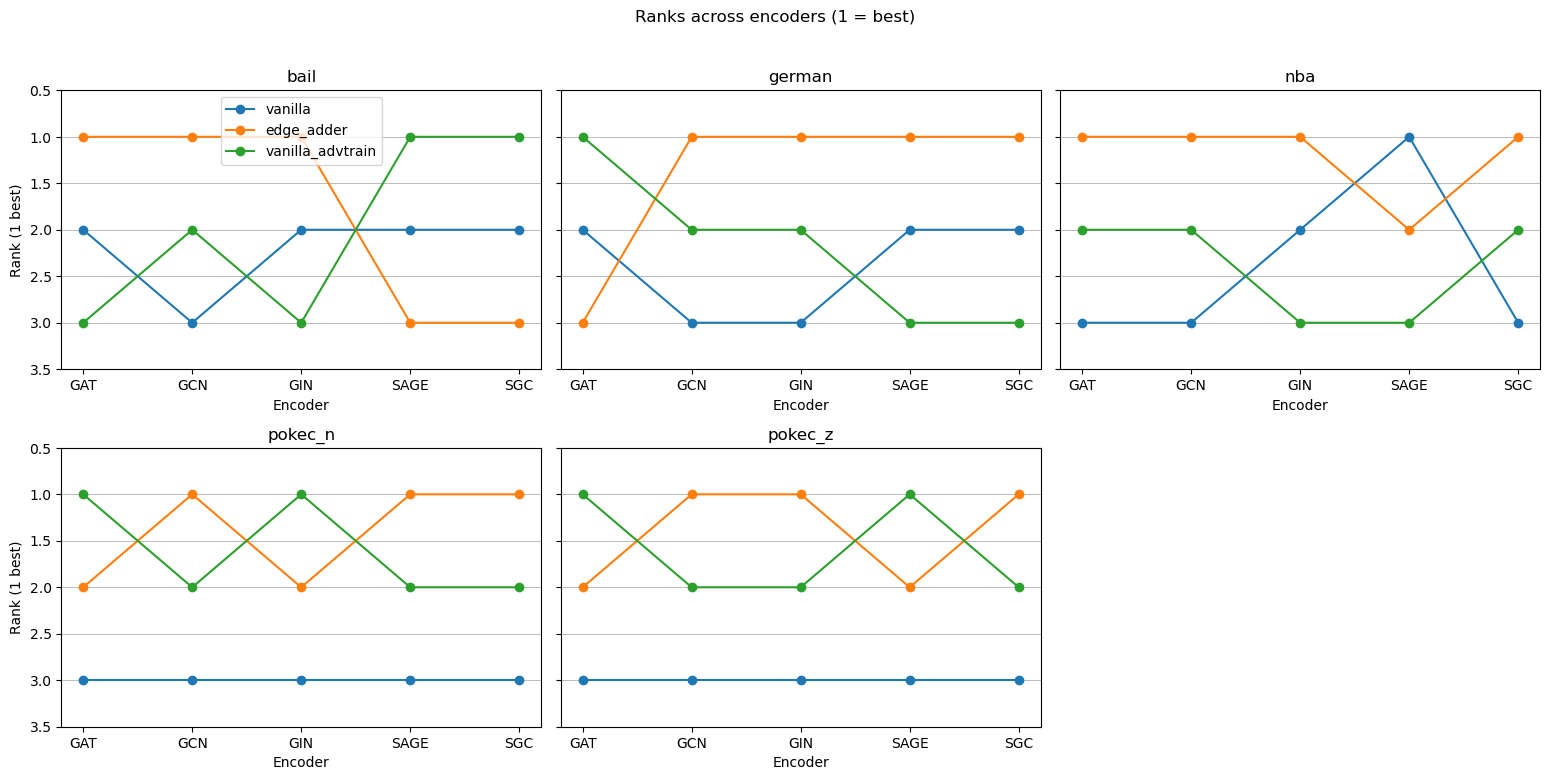

In [84]:
ranks_dict = ranks_per_dataset(pt_percent, better="min")
plot_bump_ranks(ranks_dict, ncols=3)
plt.show()

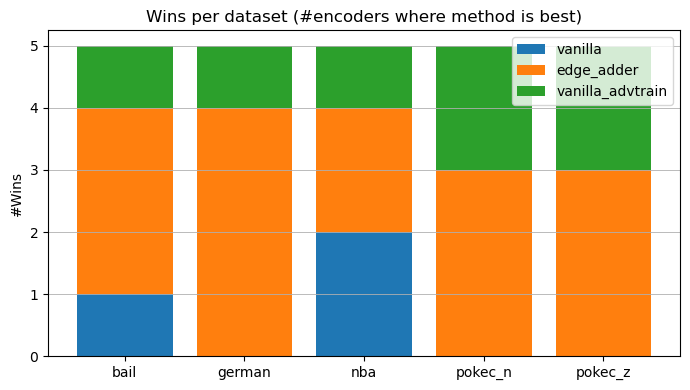

In [78]:
metric = "EO_mean"
pt_percent = (pts[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

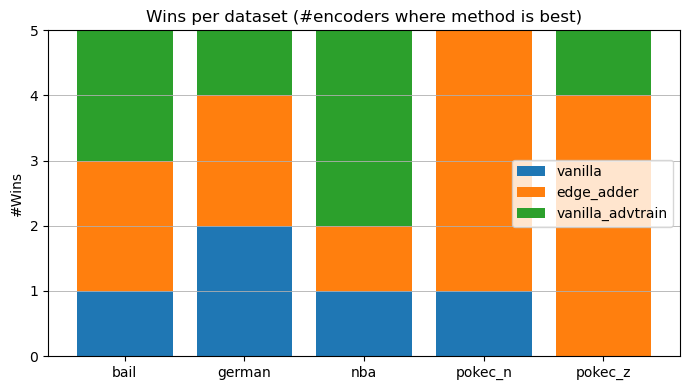

In [85]:
metric = "F1_mean"
pt_percent = (pts[metric] * 100).round(2)

counts = win_counts(pt_percent, better="max")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

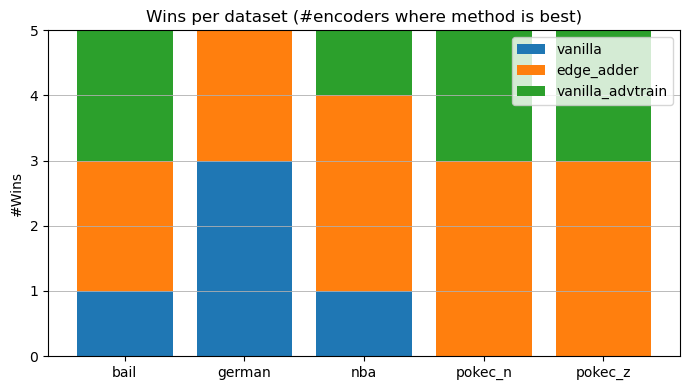

In [86]:
metric = "AUC_mean"
pt_percent = (pts[metric] * 100).round(2)

counts = win_counts(pt_percent, better="max")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from math import ceil

def pivot_to_long(pt: pd.DataFrame, value_name: str) -> pd.DataFrame:
    pt = pt.copy()
    if not isinstance(pt.index, pd.MultiIndex) or pt.index.nlevels < 2:
        raise ValueError("Expect MultiIndex index=[dataset, method].")
    pt.index = pt.index.set_names(["dataset", "method"][:pt.index.nlevels])
    df = pt.stack().rename(value_name).reset_index()
    df = df.rename(columns={df.columns[2]: "encoder"})  # stacked level name
    return df

def plot_fairness_utility_tradeoff(
    pt_fair: pd.DataFrame,
    pt_util: pd.DataFrame,
    fairness_label="DP_mean (%)",
    utility_label="F1 (%)",
    better_fairness="min",   # "min" for DP/EO; "max" otherwise
    ncols=3
):
    df = pivot_to_long(pt_fair, "fairness").merge(
        pivot_to_long(pt_util, "utility"),
        on=["dataset", "method", "encoder"],
        how="inner"
    ).dropna()

    # Make "higher is better" on y for fairness if lower is better (DP/EO)
    if better_fairness == "min":
        df["y"] = -df["fairness"]
        ylab = f"-{fairness_label} (higher is better)"
    else:
        df["y"] = df["fairness"]
        ylab = fairness_label

    datasets = list(df["dataset"].unique())
    methods  = list(df["method"].unique())
    encoders = list(df["encoder"].unique())

    # ✅ Fixed encoder→marker mapping (matches your legend expectation)
    fixed_marker_map = {
        "gat": "o", "gcn": "s", "gin": "D", "sage": "^", "sgc": "v",
        "GAT": "o", "GCN": "s", "GIN": "D", "SAGE": "^", "SGC": "v",
    }
    marker_pool = ["o", "s", "D", "^", "v", "P", "X", "<", ">", "*", "h"]
    marker_map = {}
    fallback_i = 0
    for e in encoders:
        if e in fixed_marker_map:
            marker_map[e] = fixed_marker_map[e]
        else:
            marker_map[e] = marker_pool[fallback_i % len(marker_pool)]
            fallback_i += 1

    # ✅ Consistent method→color mapping using Matplotlib’s DEFAULT cycle
    default_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    method_color = {m: default_cycle[i % len(default_cycle)] for i, m in enumerate(methods)} if default_cycle else {}

    nrows = ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 4.2*nrows))
    axes = np.array(axes).reshape(-1)

    for i, ds in enumerate(datasets):
        ax = axes[i]
        sub = df[df["dataset"] == ds]

        for m in methods:
            sm = sub[sub["method"] == m]
            if sm.empty:
                continue
            for e in encoders:
                sme = sm[sm["encoder"] == e]
                if sme.empty:
                    continue
                ax.scatter(
                    sme["utility"].to_numpy(),
                    sme["y"].to_numpy(),
                    marker=marker_map[e],
                    color=method_color.get(m, None),
                    alpha=0.85,
                )

        ax.set_title(str(ds))
        ax.set_xlabel(utility_label)
        ax.set_ylabel(ylab)
        ax.grid(True, linewidth=0.6)

    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")

    # Legends (built explicitly so they’re correct)
    method_handles = [
        Line2D([0],[0], marker="o", linestyle="None",
               color=method_color.get(m, None), label=m)
        for m in methods
    ]
    encoder_handles = [
        Line2D([0],[0], marker=marker_map[e], linestyle="None",
               color="black", label=str(e).upper())
        for e in encoders
    ]

    fig.legend(handles=encoder_handles, loc="upper left", frameon=True, title="Encoder")
    fig.legend(handles=method_handles,  loc="upper right", frameon=True, title="Method")

    plt.tight_layout()
    return fig, axes, df


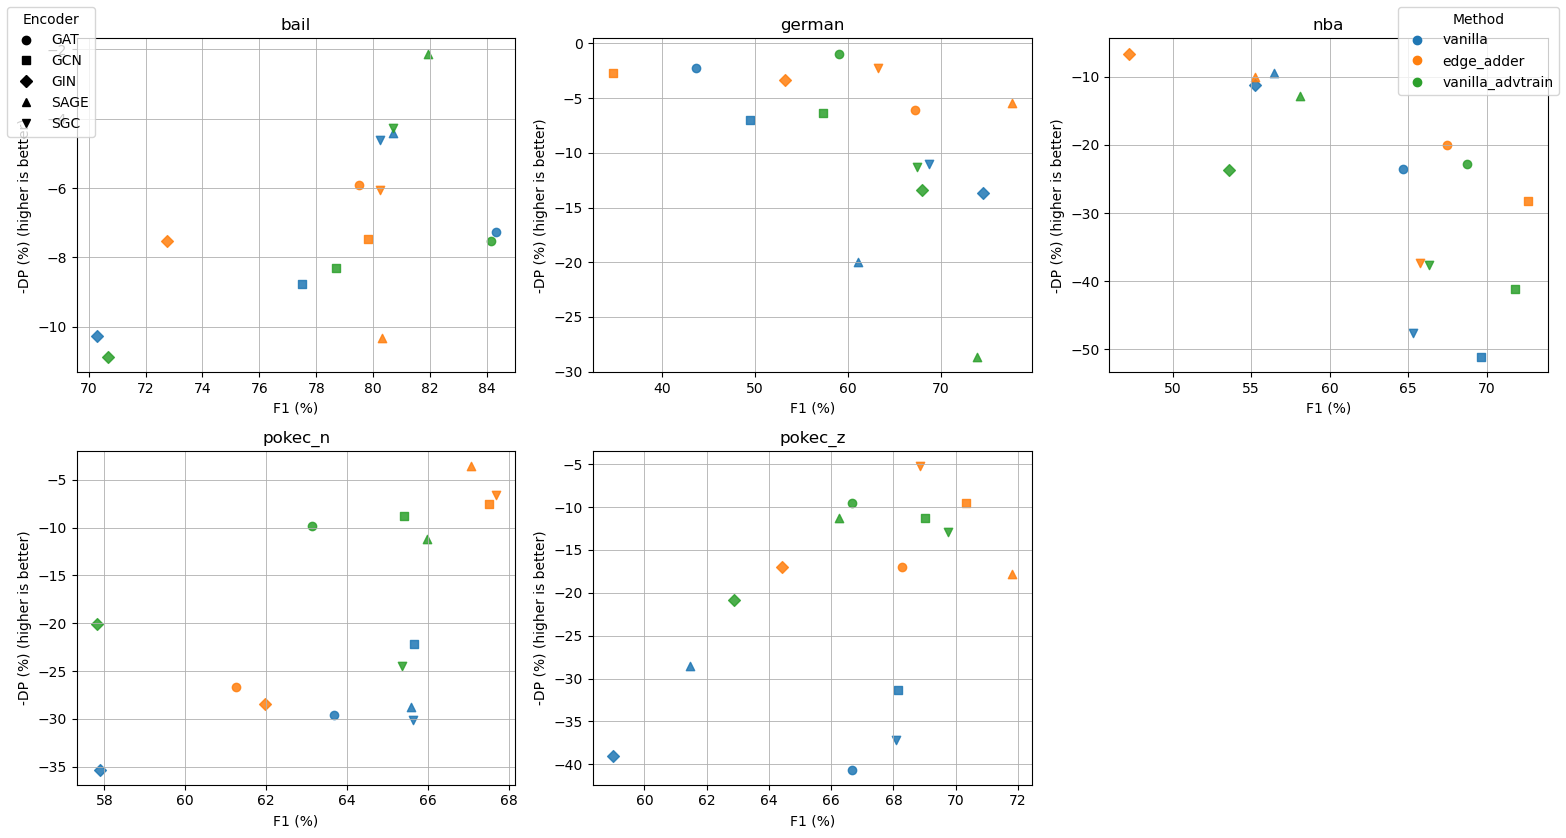

In [96]:
pt_dp = (pts["DP_mean"] * 100).round(2)
pt_f1 = (pts["F1_mean"] * 100).round(2)   # adjust if your F1 is already in %

plot_fairness_utility_tradeoff(
    pt_fair=pt_dp,
    pt_util=pt_f1,
    fairness_label="DP (%)",
    utility_label="F1 (%)",
    better_fairness="min",
    ncols=3
)
plt.show()